Claude summary

- Input: 29,361 cells × 27,055 genes (after regex/biotype/UMI filters)                                                                                                          
- Feature genes selected: 4,321 (15.97%) passing T_vm > 0.1 and total UMI > 100                                                                                                 
- Metacells: 274 metacells (20 outlier cells not assigned)  

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
from pathlib import Path

In [5]:
adata = sc.read_h5ad("results/05/zmanseq_cells.h5ad")
madata = sc.read_h5ad("results/05/zmanseq_metacells.h5ad")

In [9]:
%matplotlib inline

In [13]:
adata.obs

,well_coordinates,Amp_batch_ID,Subject_ID,Number_of_cells,Seq_batch_ID,Pool_barcode,Pool_barcode_i5,Cell_barcode,Mouse,time_assignment,...,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,metacell,dissolved,metacell_level,metacell_name
Well_ID,,,,,,,,,,,,,,,,,,,,,
W2035161,A1,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,CTATTCG,Mouse_3,Negative,...,1047,2697.0,34.445680,43.974787,56.507230,79.718205,179,False,1,M179.80
W2035162,A2,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGATCCG,Mouse_3,Negative,...,1174,3105.0,35.619968,45.700483,57.616747,78.293076,24,False,1,M24.76
W2035163,A3,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,GTATGCG,Mouse_3,18H,...,484,1037.0,40.790743,54.676953,72.613308,100.000000,183,False,1,M183.81
W2035164,A4,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGACGTC,Mouse_3,Negative,...,1126,2631.0,27.822121,38.008362,51.159255,76.206765,190,False,1,M190.98
W2035165,A5,AB5234,SPID_SEQ,1,SB171,AGATGGTC,TGCTCGAA,TGTCACG,Mouse_3,Negative,...,235,374.0,40.641711,63.903743,90.641711,100.000000,141,False,1,M141.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W2526462,G22,AB6517,SPID_SEQ,1,SB179,AGCCATCT,CTAACGGA,AAGGCTA,Mouse_14,36H,...,423,699.0,37.052933,51.502146,68.097282,100.000000,187,False,1,M187.69
W2526463,G23,AB6517,SPID_SEQ,1,SB179,AGCCATCT,CTAACGGA,CGTCAGA,Mouse_14,48H,...,293,488.0,41.803279,60.450820,80.942623,100.000000,69,False,1,M69.39
W2526464,G24,AB6517,SPID_SEQ,1,SB179,AGCCATCT,CTAACGGA,CCATGAC,Mouse_14,24H,...,268,451.0,41.906874,62.749446,84.922395,100.000000,31,False,1,M31.98


<Axes: xlabel='sc_x', ylabel='sc_y'>

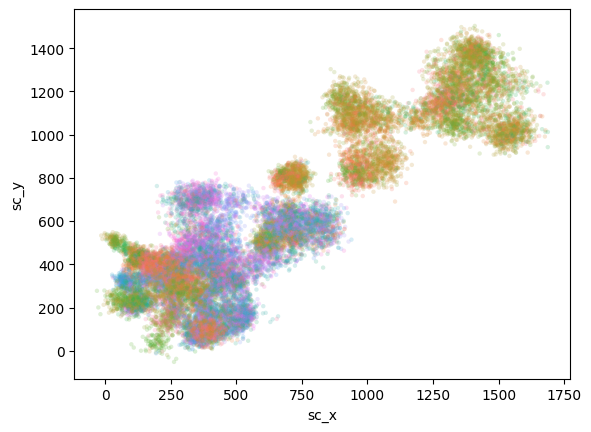

In [20]:
sns.scatterplot(
    adata.obs, 
    x="sc_x", 
    y="sc_y", 
    hue="metacell_name", 
    s=10, 
    linewidth=0, 
    alpha=0.2, legend=False
)

todo: rerun with just the macrophage/monocytes

In [15]:
madata.obs

,grouped,total_umis,__zeros_downsample_umis,sc_x,sc_y
M0.04,113,79301,381,1177.771852,1014.824462
M1.95,157,291281,493,187.847972,398.090183
M2.20,130,319911,600,353.503149,147.171095
M3.55,118,156489,472,257.092901,398.459655
M4.12,178,140548,400,1184.084498,1037.123111
...,...,...,...,...,...
M269.64,147,174200,446,241.294452,153.694409
M270.67,100,185363,357,605.419975,604.834219
M271.74,159,262418,386,442.667807,431.573752
M272.99,32,227295,856,283.812401,357.600826


In [14]:
madata.obs['sc_x'] = adata.obs.groupby('metacell_name')['sc_x'].mean().loc[madata.obs.index]
madata.obs['sc_y'] = adata.obs.groupby('metacell_name')['sc_y'].mean().loc[madata.obs.index]


/tmp/ipykernel_1502933/3994713146.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  madata.obs['sc_x'] = adata.obs.groupby('metacell_name')['sc_x'].mean().loc[madata.obs.index]
/tmp/ipykernel_1502933/3994713146.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  madata.obs['sc_y'] = adata.obs.groupby('metacell_name')['sc_y'].mean().loc[madata.obs.index]


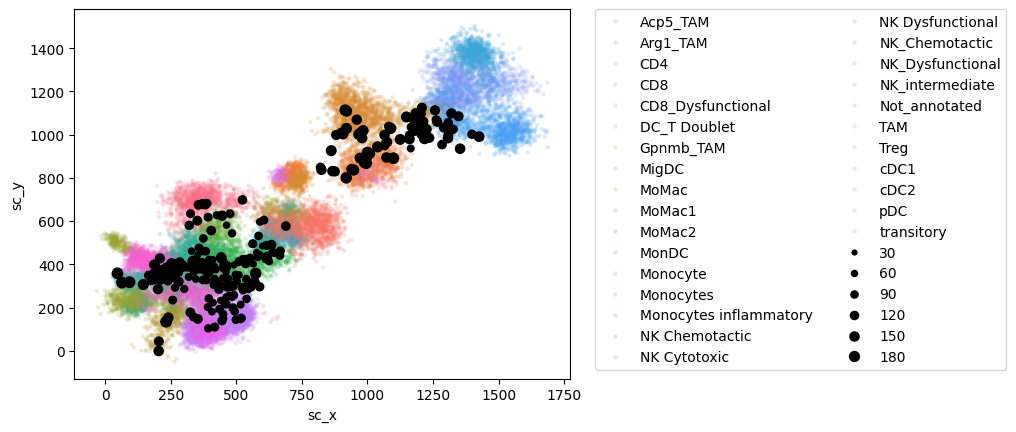

In [19]:
sns.scatterplot(
    adata.obs, 
    x="sc_x", 
    y="sc_y", 
    hue="cluster_colors", 
    s=10, 
    linewidth=0, 
    alpha=0.2
)

sns.scatterplot(
    madata.obs, 
    x="sc_x", 
    y="sc_y", 
    size="grouped", 
    linewidth=0, color='black')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., ncol=2)

plt.show()